# NovaCat Photometry — Operations Notebook

Query the dedicated NovaCat Photometry DynamoDB table.

**Setup:** Run the *Imports & Setup* cell first, then use any section independently.

---

**Section 1** — Table Dashboard (full-table aggregate stats)
**Section 2** — Per-Nova Views
- 2a Photometry Overview (row count + envelope metadata)
- 2b All Rows (full light curve data)
- 2c Band Summary (counts and ranges per band)
- 2d Regime Summary (counts per wavelength regime)
- 2e Provenance (breakdown by source/bibcode)

**Section 3** — Multi-Nova Comparison
**Section 4** — Quick Plots (light curves, band histograms)

## Imports & Setup

In [1]:
import sys
import os

# Add tools directory to path so we can import the modules
# Adjust this path if the notebook lives somewhere other than notebooks/
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'tools'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

from novacat_phot_query import NovaCatPhotQuery

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 120)

# Instantiate
pq = NovaCatPhotQuery()

print('Ready.')

Ready.


---
## Section 1 — Photometry Table Dashboard

Aggregate counts across the entire NovaCatPhotometry table.

> **Note:** Uses a full table scan. Fast at current catalog size.
> When the catalog grows, this will be replaced by a `STATS` item read.

In [2]:
stats = pq.dashboard()
df_stats = pq.dashboard_df()
df_stats

,metric,count
0,Total Rows,60
1,Nova Count,1
2,Band Count,3
3,Detection Count,60
4,Upper Limit Count,0
5,Regime Breakdown — optical,60
6,Quality Flag Breakdown — 0,60


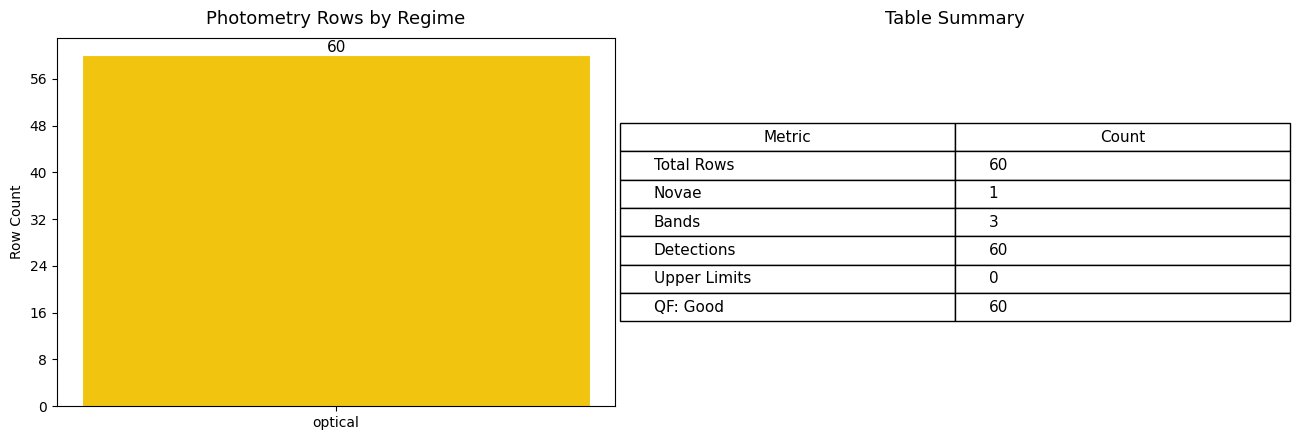

In [3]:
# ── Regime breakdown (bar chart) + summary stats table ─────────────────────────
regime = stats.get('regime_breakdown', {})
qf = stats.get('quality_flag_breakdown', {})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bar chart — rows by regime
if regime:
    regime_labels = list(regime.keys())
    regime_values = list(regime.values())
    regime_colors = {
        'optical': '#f1c40f',
        'uv':      '#9b59b6',
        'nir':     '#e67e22',
        'mir':     '#e74c3c',
        'radio':   '#3498db',
        'xray':    '#1abc9c',
        'gamma':   '#95a5a6',
    }
    bar_colors = [regime_colors.get(r, '#7f8c8d') for r in regime_labels]

    axes[0].bar(regime_labels, regime_values, color=bar_colors, edgecolor='white', linewidth=0.8)
    axes[0].set_title('Photometry Rows by Regime', fontsize=13, pad=10)
    axes[0].set_ylabel('Row Count')
    axes[0].yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    for i, v in enumerate(regime_values):
        axes[0].text(i, v + 0.05, str(v), ha='center', va='bottom', fontsize=11)
else:
    axes[0].text(0.5, 0.5, 'No data', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Photometry Rows by Regime', fontsize=13, pad=10)

# Summary stats table
summary_rows = [
    ['Total Rows',      stats['total_rows']],
    ['Novae',           stats['nova_count']],
    ['Bands',           stats['band_count']],
    ['Detections',      stats['detection_count']],
    ['Upper Limits',    stats['upper_limit_count']],
]
# Add quality flag breakdown
qf_labels = {0: 'Good', 1: 'Uncertain', 2: 'Poor', 3: 'Bad'}
for flag_val, count in sorted(qf.items(), key=lambda x: str(x[0])):
    label = qf_labels.get(int(flag_val), f'Flag {flag_val}') if str(flag_val).isdigit() else f'Flag {flag_val}'
    summary_rows.append([f'QF: {label}', count])

axes[1].axis('off')
tbl = axes[1].table(
    cellText=summary_rows,
    colLabels=['Metric', 'Count'],
    loc='center',
    cellLoc='left',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 1.6)
axes[1].set_title('Table Summary', fontsize=13, pad=10)

plt.tight_layout()
plt.show()

---
## Section 2 — Per-Nova Views

Set `NOVA_NAME` once; all cells in this section use it.

In [4]:
# NOVA_NAME = 'V4739 Sgr'  # ← change this
NOVA_NAME = 'V2572 Sgr'  # ← change this

### 2a — Photometry Overview

In [5]:
# Row count (fast — uses SELECT=COUNT, no item fetch)
count = pq.row_count(NOVA_NAME)
print(f'{NOVA_NAME}: {count} photometry row(s) in DDB')

# Envelope metadata from the main NovaCat table
env = pq.envelope(NOVA_NAME)
if env:
    print()
    print(f"Product type:         {env.get('product_type')}")
    print(f"Schema version:       {env.get('schema_version')}")
    print(f"Last ingestion at:    {env.get('last_ingestion_at')}")
    print(f"Ingestion source:     {env.get('ingestion_source') or env.get('last_ingestion_source')}")
    print(f"Ingestion count:      {env.get('ingestion_count')}")
    print(f"Created:              {env.get('created_at')}")
    print(f"Updated:              {env.get('updated_at')}")
else:
    print('No PRODUCT#PHOTOMETRY_TABLE envelope item found in main table.')

V2572 Sgr: 60 photometry row(s) in DDB

Product type:         PHOTOMETRY_TABLE
Schema version:       1
Last ingestion at:    2026-04-01T15:43:57Z
Ingestion source:     ticket_ingestion
Ingestion count:      1
Created:              2026-04-01T15:43:57Z
Updated:              2026-04-01T15:43:57Z


### 2b — All Photometry Rows

Full light curve data. Use the optional filters to narrow results.

In [6]:
# Optional filters — set to None to disable
BAND_FILTER   = None   # e.g. 'JohnsonCousins_V'
REGIME_FILTER = None   # e.g. 'optical', 'xray', 'radio'

df_rows = pq.rows(NOVA_NAME, band=BAND_FILTER, regime=REGIME_FILTER)
print(f'{len(df_rows)} row(s) found')
df_rows

60 row(s) found


,row_id,time_mjd,band_id,regime,filter_name,magnitude,mag_err,flux_density,flux_density_err,flux_density_unit,count_rate,count_rate_err,is_upper_limit,quality_flag,phot_system,mag_system,telescope,instrument,bibcode,ingested_at
0,7b4a6fbc-02b7-afb5-d892-8b0904919f60,40485.40,Generic_B,optical,None,11.10,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
1,792d2483-a0bd-14ff-874b-401383c4cf93,40485.40,Generic_V,optical,None,11.24,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
2,36caa780-ef2d-4fb4-41fd-9310df286a5e,40485.40,Generic_U,optical,None,10.51,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
3,2077f1f7-10d8-59e5-f48e-86032e13bebb,40485.44,Generic_V,optical,None,11.20,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
4,21d354db-00fe-c28d-f06e-a911a5afeb89,40485.44,Generic_B,optical,None,11.06,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
5,5d426f7c-0e76-5027-9627-0de1d98c75dc,40485.44,Generic_U,optical,None,10.55,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
6,9632ffa8-cbf0-3bc4-bffc-0a249d2ae089,40486.37,Generic_V,optical,None,11.22,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
7,8a17ff64-126b-0d56-b686-f56fe8c37d14,40486.37,Generic_U,optical,None,10.56,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
8,f5c24e16-95ee-bf90-8867-8af78ad288e2,40486.37,Generic_B,optical,None,11.11,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z
9,a4a30cc3-6e9e-5f3a-bdc5-0d2acaac92dc,40491.40,Generic_U,optical,None,10.68,0.02,NaN,NaN,None,NaN,NaN,False,0,None,None,Auckland Observatory 50 cm Zeiss Cassegrain Reflector,None,1970IBVS..475....1B,2026-04-01T15:43:57Z


In [ ]:
# Upper limits only
df_ul = pq.rows(NOVA_NAME, upper_limits=True)
print(f'{len(df_ul)} upper limit(s) found')
df_ul

### 2c — Band Summary

One row per photometric band with counts, magnitude range, and MJD time span.

In [4]:
df_bands = pq.band_summary(NOVA_NAME)
print(f'{len(df_bands)} band(s)')
df_bands

NameError: name 'NOVA_NAME' is not defined

In [ ]:
# Band breakdown bar chart
if not df_bands.empty:
    fig, ax = plt.subplots(figsize=(max(6, len(df_bands) * 0.8), 4))

    colors_by_regime = {
        'optical': '#f1c40f',
        'uv':      '#9b59b6',
        'nir':     '#e67e22',
        'mir':     '#e74c3c',
        'radio':   '#3498db',
        'xray':    '#1abc9c',
        'gamma':   '#95a5a6',
    }
    bar_colors = [colors_by_regime.get(str(r), '#7f8c8d') for r in df_bands['regime']]

    ax.bar(df_bands['band_id'].astype(str), df_bands['total'], color=bar_colors, edgecolor='white')
    ax.set_title(f'Photometry Rows by Band — {NOVA_NAME}', fontsize=12)
    ax.set_ylabel('Row Count')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No band data to plot.')

### 2d — Regime Summary

One row per wavelength regime (optical, UV, NIR, X-ray, radio, etc.).

In [ ]:
df_regimes = pq.regime_summary(NOVA_NAME)
print(f'{len(df_regimes)} regime(s)')
df_regimes

### 2e — Provenance

Breakdown by source publication / bibcode. Shows how many rows came from each paper or catalog.

In [ ]:
df_prov = pq.provenance(NOVA_NAME)
print(f'{len(df_prov)} source(s)')
df_prov

---
## Section 3 — Multi-Nova Comparison

Compare photometry coverage across several novae at once.

In [ ]:
# Add nova names as you ingest them
NOVA_LIST = ['V4739 Sgr']

rows = []
for name in NOVA_LIST:
    try:
        nova_id = pq.resolve_nova_id(name)
        count = pq.row_count(name)
        df_b = pq.band_summary(name)
        df_r = pq.regime_summary(name)
        env = pq.envelope(name)
        rows.append({
            'name':             name,
            'nova_id':          nova_id,
            'total_rows':       count,
            'n_bands':          len(df_b),
            'n_regimes':        len(df_r),
            'regimes':          ', '.join(df_r['regime'].dropna().tolist()) if not df_r.empty else '',
            'last_ingestion':   (env or {}).get('last_ingestion_at'),
            'ingestion_count':  (env or {}).get('ingestion_count'),
        })
    except ValueError as e:
        rows.append({'name': name, 'nova_id': f'NOT FOUND: {e}'})

pd.DataFrame(rows)

---
## Section 4 — Quick Plots

### 4a — Light Curve (magnitude vs MJD)

Plots detections only (upper limits excluded). Magnitude axis is inverted (brighter = up).

In [ ]:
PLOT_NOVA = NOVA_NAME  # or override with a different name

df_plot = pq.rows(PLOT_NOVA, upper_limits=False)

if df_plot.empty or df_plot['magnitude'].isna().all():
    print('No magnitude data to plot.')
else:
    df_mag = df_plot.dropna(subset=['magnitude', 'time_mjd'])

    bands = df_mag['band_id'].unique()
    # Color palette for up to ~12 bands
    cmap = plt.cm.get_cmap('tab10', max(len(bands), 1))

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, band in enumerate(sorted(bands)):
        subset = df_mag[df_mag['band_id'] == band]
        ax.scatter(
            subset['time_mjd'], subset['magnitude'],
            s=12, label=band, color=cmap(i), alpha=0.7, zorder=3,
        )
        # Error bars if available
        if 'mag_err' in subset.columns and subset['mag_err'].notna().any():
            ax.errorbar(
                subset['time_mjd'], subset['magnitude'],
                yerr=subset['mag_err'],
                fmt='none', ecolor=cmap(i), alpha=0.3, zorder=2,
            )

    ax.invert_yaxis()  # brighter = up
    ax.set_xlabel('MJD')
    ax.set_ylabel('Magnitude')
    ax.set_title(f'Light Curve — {PLOT_NOVA}', fontsize=13)
    ax.legend(fontsize=8, ncol=min(len(bands), 4), loc='upper right')
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4b — Flux Density Light Curve (radio / X-ray)

In [ ]:
# Flux density plot for non-magnitude regimes (radio, xray, gamma)
df_flux = pq.rows(PLOT_NOVA, upper_limits=False)

if df_flux.empty or df_flux['flux_density'].isna().all():
    print('No flux density data to plot.')
else:
    df_fd = df_flux.dropna(subset=['flux_density', 'time_mjd'])

    bands = df_fd['band_id'].unique()
    cmap = plt.cm.get_cmap('tab10', max(len(bands), 1))

    fig, ax = plt.subplots(figsize=(12, 5))
    for i, band in enumerate(sorted(bands)):
        subset = df_fd[df_fd['band_id'] == band]
        unit = subset['flux_density_unit'].dropna().iloc[0] if subset['flux_density_unit'].notna().any() else '?'
        ax.scatter(
            subset['time_mjd'], subset['flux_density'],
            s=12, label=f'{band} ({unit})', color=cmap(i), alpha=0.7, zorder=3,
        )
        if 'flux_density_err' in subset.columns and subset['flux_density_err'].notna().any():
            ax.errorbar(
                subset['time_mjd'], subset['flux_density'],
                yerr=subset['flux_density_err'],
                fmt='none', ecolor=cmap(i), alpha=0.3, zorder=2,
            )

    ax.set_xlabel('MJD')
    ax.set_ylabel('Flux Density')
    ax.set_title(f'Flux Density Light Curve — {PLOT_NOVA}', fontsize=13)
    ax.legend(fontsize=8, ncol=min(len(bands), 4), loc='upper right')
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

### 4c — Temporal Coverage by Band

In [ ]:
# Time coverage strips — one horizontal bar per band showing MJD span
df_bands_plot = pq.band_summary(PLOT_NOVA)

if df_bands_plot.empty:
    print('No band data to plot.')
else:
    df_bp = df_bands_plot.dropna(subset=['mjd_min', 'mjd_max']).sort_values('mjd_min')

    colors_by_regime = {
        'optical': '#f1c40f',
        'uv':      '#9b59b6',
        'nir':     '#e67e22',
        'mir':     '#e74c3c',
        'radio':   '#3498db',
        'xray':    '#1abc9c',
        'gamma':   '#95a5a6',
    }

    fig, ax = plt.subplots(figsize=(12, max(3, len(df_bp) * 0.4)))
    for i, (_, row) in enumerate(df_bp.iterrows()):
        color = colors_by_regime.get(str(row.get('regime')), '#7f8c8d')
        duration = max(row['mjd_max'] - row['mjd_min'], 0.5)  # min width for visibility
        ax.barh(i, duration, left=row['mjd_min'], height=0.6, color=color, edgecolor='white')
        ax.text(row['mjd_min'] - 1, i, f"{row['band_id']} ({int(row['total'])})",
                ha='right', va='center', fontsize=9)

    ax.set_yticks([])
    ax.set_xlabel('MJD')
    ax.set_title(f'Temporal Coverage by Band — {PLOT_NOVA}', fontsize=12)
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()